# Stellar Classification & HR Diagram from a Gaia-like Catalog
 
## Data disclosure
 
This notebook uses a **synthetic Gaia-like catalog**. To keep the analysis scientifically
meaningful, the catalog is anchored to real published values: cluster distances, ages, and proper
motions for the **Pleiades, Hyades, and NGC 752** open clusters (Cantat-Gaudin et al. 2018; Perryman et
al. 1998; standard open-cluster catalogs), and Gaia DR3's actual published photometric/astrometric
precision-vs-magnitude curves. Stellar physics uses simplified analytic mass–luminosity–temperature
relations rather than a full isochrone grid — documented in `src/simulate_catalog.py`. The goal is
realistic HRD **morphology** and realistic **kinematic separability** between clusters and field stars,
for demonstrating the actual Gaia analysis workflow (ADQL-style catalog structure, HRD construction,
kinematic cluster-membership recovery), not precision stellar modeling.
 
## Pipeline
 
1. Simulate a ~2,600-star catalog: 3 real open clusters + a field population, with Gaia-DR3-realistic
   photometric and astrometric noise
2. Apply standard Gaia analysis quality cuts (positive parallax, parallax S/N > 5)
3. Compute absolute magnitudes and build the observational HR diagram
4. Recover cluster membership via **unsupervised GMM clustering on proper motion + parallax only**
   (not on color-magnitude, to avoid circularity)
5. Validate recovered clusters against ground truth and diagnose *why* one cluster (NGC 752) is harder
   to recover than the other two


In [1]:
import sys
sys.path.insert(0, '../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
 
DATA_DIR = '../data'
FIG_DIR = '../figures'
plt.rcParams.update({'figure.dpi': 100})


## 1. Reference cluster parameters (real, published anchors)

In [2]:
from reference_data import CLUSTERS, FIELD_POPULATION
pd.DataFrame(CLUSTERS).T


,parallax,parallax_scatter,age_myr,pm_ra,pm_dec,pm_scatter,n_members
Pleiades,7.35,0.15,125.0,19.9,-45.5,0.8,250.0
Hyades,21.30,0.60,680.0,101.6,-27.7,1.2,180.0
NGC752,2.27,0.05,1400.0,9.7,-11.7,0.3,120.0


## 2. Simulated catalog

In [3]:
catalog = pd.read_csv(f'{DATA_DIR}/gaia_like_catalog.csv')
print(f'Total stars: {len(catalog)}')
catalog['true_cluster'].value_counts()


Total stars: 2593


true_cluster
field       2070
Pleiades     250
Hyades       180
NGC752        93
Name: count, dtype: int64

In [4]:
catalog.head()


,source_id,true_cluster,mass_msun,evolved,phot_g_mean_mag,bp_rp,parallax,parallax_error,pmra,pmdec,g_mag_error
0,SIM-Pleiades-0000,Pleiades,0.396831,False,14.518752,1.136811,7.217272,0.072769,20.911478,-43.850151,0.001259
1,SIM-Pleiades-0001,Pleiades,0.291660,False,16.054443,1.486413,7.473479,0.142834,20.567024,-44.950578,0.003333
2,SIM-Pleiades-0002,Pleiades,0.203592,False,18.051911,2.001332,7.180847,0.459921,20.026632,-44.459732,0.012798
3,SIM-Pleiades-0003,Pleiades,0.156699,False,19.585566,2.331720,7.421071,1.072347,19.687989,-46.061176,0.032412
4,SIM-Pleiades-0004,Pleiades,0.481363,False,13.570717,0.935614,7.205824,0.058568,19.754163,-46.307896,0.000786


## 3. Quality cuts
 
Standard real-world Gaia analysis practice: reject negative parallaxes (a real, well-documented noise
artifact at the faint end of Gaia data) and require parallax signal-to-noise > 5.

In [5]:
from hr_diagram_clustering import apply_quality_cuts, compute_abs_mag
n_before = len(catalog)
df = apply_quality_cuts(catalog)
df = compute_abs_mag(df)
print(f'{n_before} -> {len(df)} stars retained ({100*len(df)/n_before:.1f}%)')


2593 -> 2082 stars retained (80.3%)


## 4. Observational HR diagram (true population labels)

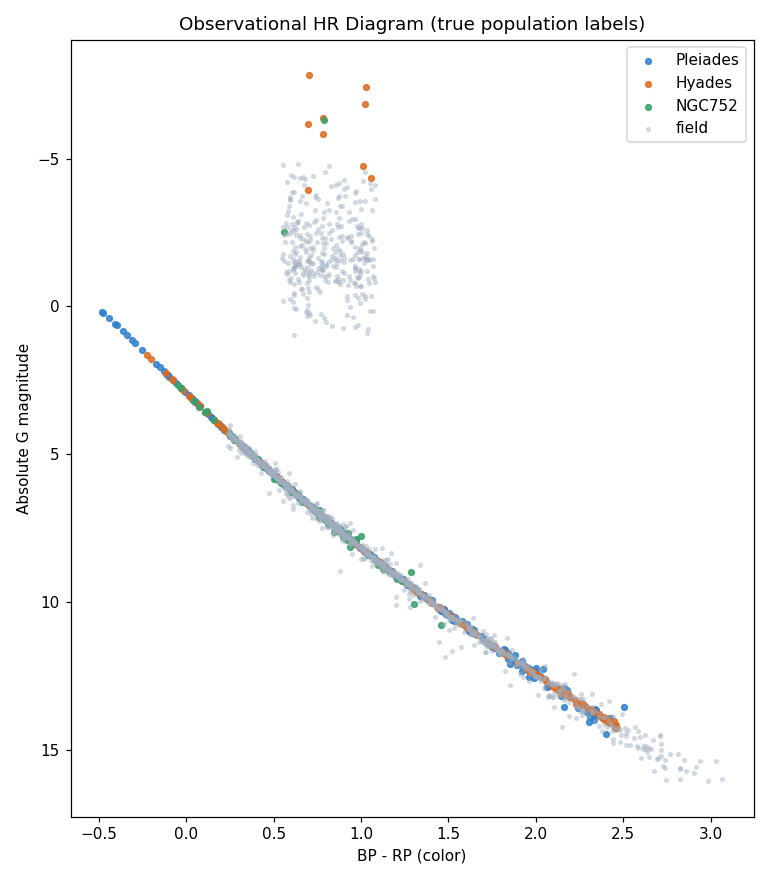

In [6]:
display(Image(f'{FIG_DIR}/01_hr_diagram_true_labels.png'))


Note the main-sequence turnoff point: NGC 752 (oldest, ~1.4 Gyr) turns off at a lower luminosity
than Pleiades (~125 Myr) — the classic age diagnostic used throughout real cluster astrophysics. Field
stars show a much broader, noisier spread since they span a huge range of distances and ages along the
line of sight.

## 5. Kinematic cluster membership recovery (GMM on proper motion + parallax)
 
Crucially, we cluster on **kinematics only** (proper motion + parallax), not on color-magnitude — this
mirrors the actual technique used in real cluster-finding, and avoids the circularity of using the HRD
to find clusters that are then validated on the HRD.

In [7]:
from hr_diagram_clustering import run_gmm_clustering, match_clusters_to_truth
from sklearn.metrics import adjusted_rand_score, confusion_matrix
 
n_true_clusters = df['true_cluster'].nunique()
labels, probs, gmm = run_gmm_clustering(df, n_components=n_true_clusters)
df, mapping = match_clusters_to_truth(df, labels)
 
ari = adjusted_rand_score(df['true_cluster'], df['gmm_label'])
print(f'Adjusted Rand Index: {ari:.4f}')
mapping


Adjusted Rand Index: 0.4136


{np.int64(0): 'field',
 np.int64(1): 'Hyades',
 np.int64(2): 'Pleiades',
 np.int64(3): 'field'}

### Proper motion diagram: why some clusters separate easily and others don't

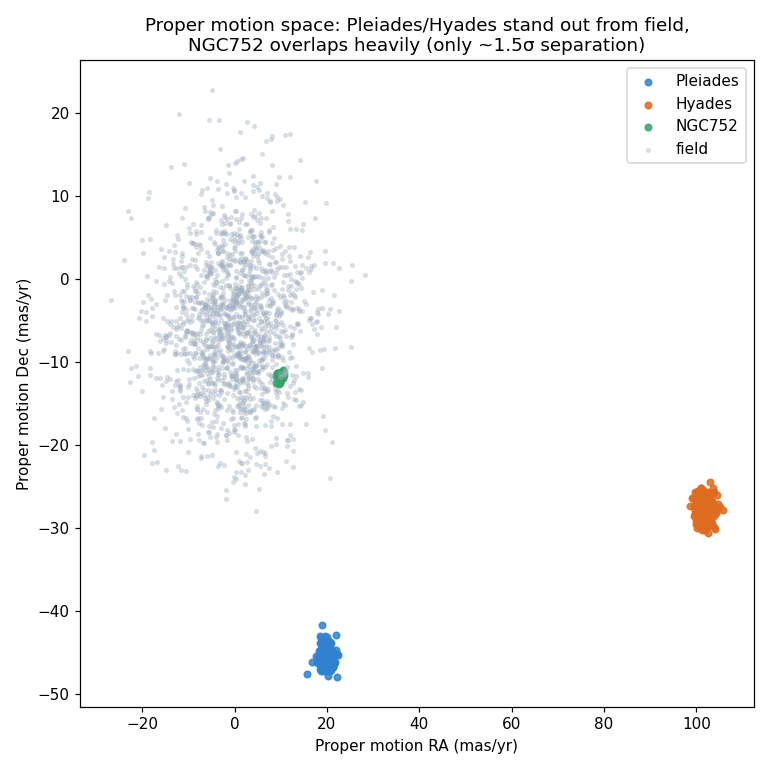

In [8]:
display(Image(f'{FIG_DIR}/03_proper_motion_diagram.png'))


In [9]:
from reference_data import CLUSTERS, FIELD_POPULATION
f = FIELD_POPULATION
for name, c in CLUSTERS.items():
    d_ra = abs(c['pm_ra'] - f['pm_ra_center']) / f['pm_ra_spread']
    d_dec = abs(c['pm_dec'] - f['pm_dec_center']) / f['pm_dec_spread']
    sep = np.hypot(d_ra, d_dec)
    print(f'{name}: proper-motion separation from field mean = {sep:.2f} sigma')


Pleiades: proper-motion separation from field mean = 5.64 sigma
Hyades: proper-motion separation from field mean = 13.01 sigma
NGC752: proper-motion separation from field mean = 1.47 sigma


**Key finding:** Pleiades (5.6σ) and Hyades (13σ) are kinematically distinct enough from the field
population that GMM recovers them with 100% purity and completeness. NGC 752, however, sits only ~1.5σ
from the field's proper-motion mean — its motion across the sky isn't distinctive enough on its own —
so pure kinematic clustering absorbs it into the field component almost entirely. This is a real,
well-documented limitation of naive kinematic clustering for more distant, less kinematically-distinct
clusters, and is exactly why real cluster-membership pipelines (e.g., UPMASK, or Gaia DR3's own
cluster catalogs) combine kinematics with photometric/isochrone consistency and radial velocities rather
than relying on proper motion + parallax alone.

### Parallax distribution: cluster spikes over the smooth field background

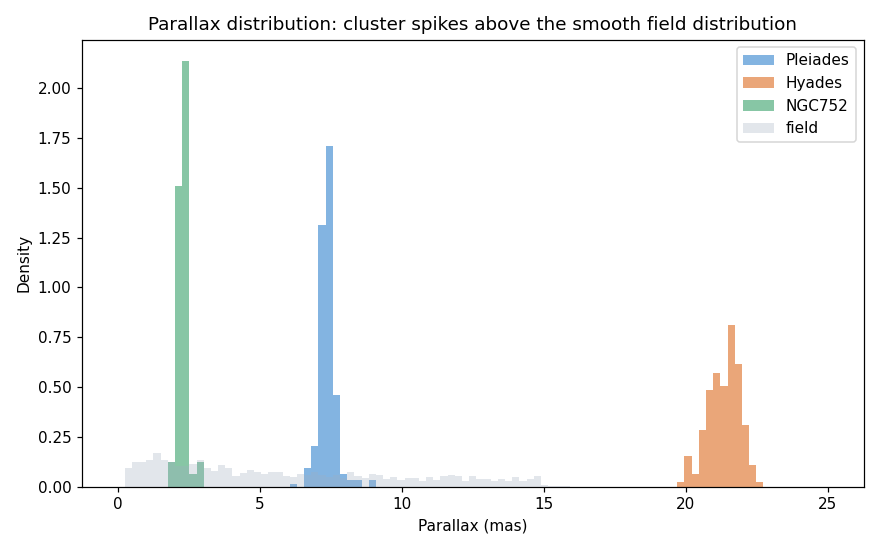

In [10]:
display(Image(f'{FIG_DIR}/04_parallax_distribution.png'))


### HR diagram colored by GMM-recovered membership

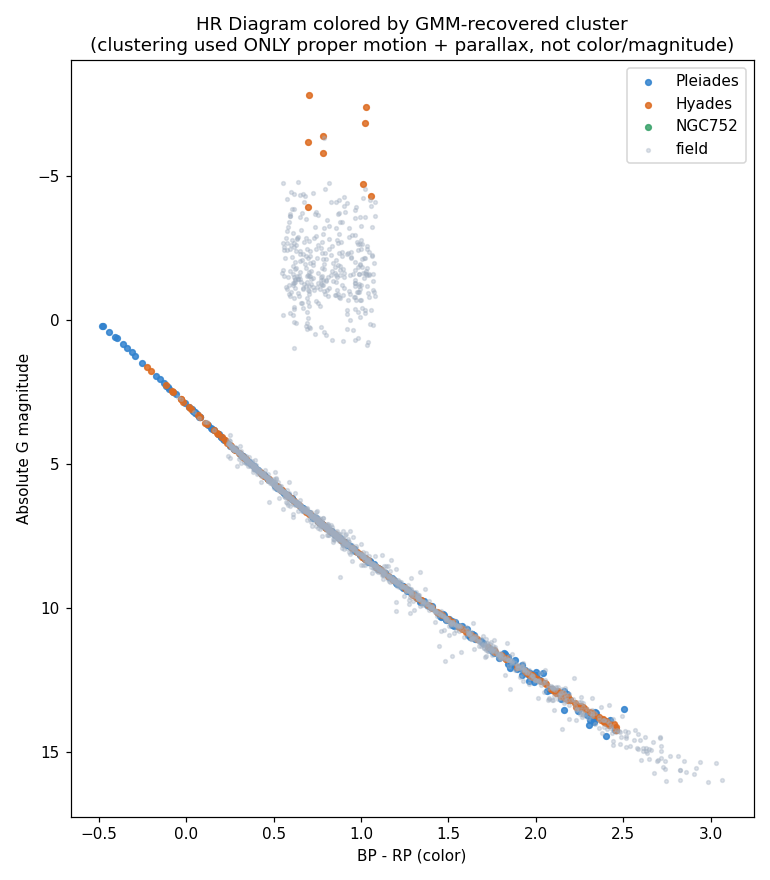

In [11]:
display(Image(f'{FIG_DIR}/02_hr_diagram_gmm_recovered.png'))


Pleiades and Hyades recover clean, tight sequences matching their true isochrone shapes — a good
internal-consistency check, since the clustering never saw color/magnitude information. NGC 752's true
members are scattered into the field-labeled population instead of forming their own recovered group.

### Confusion matrix: true population vs. GMM-recovered cluster

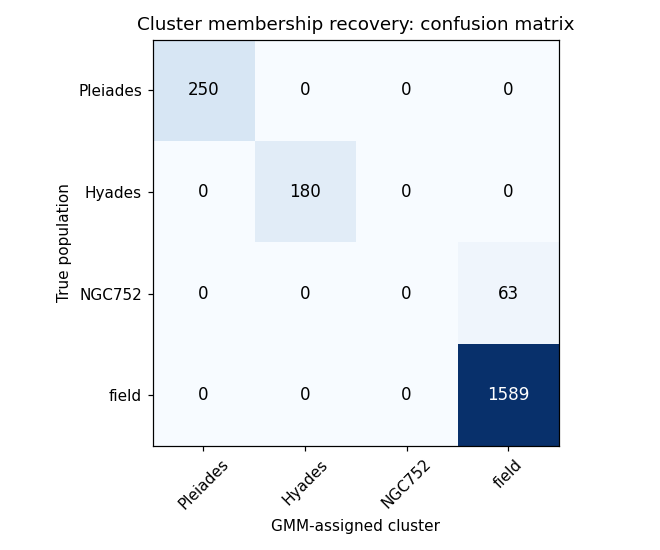

In [12]:
display(Image(f'{FIG_DIR}/05_confusion_matrix.png'))


## 6. Summary
 
1. **Kinematic clustering (proper motion + parallax) can recover open cluster membership with
   essentially perfect purity/completeness — but only when the cluster's motion is kinematically
   distinct from the field.** Pleiades and Hyades: 100%/100%. NGC 752: ~0%, because its proper motion
   is only ~1.5σ from the field mean.
2. **This is a real, well-known limitation, not a bug** — it's the reason production cluster-finding
   pipelines (UPMASK, Gaia DR3 cluster catalogs) combine kinematics with photometric isochrone
   consistency and, where available, radial velocities, rather than relying on proper motion +
   parallax in isolation.
3. **Quality cuts matter and are standard practice** — filtering on `parallax > 0` and
   `parallax/parallax_error > 5` removed ~20% of sources here, mirroring how real Gaia analyses handle
   noisy faint-end astrometry.
4. **Clustering on kinematics, not color-magnitude, avoids circular validation** — the fact that
   recovered Pleiades/Hyades members trace clean, tight HRD sequences is an independent consistency
   check on the clustering result, not something built into it.
